<div style="width: 100%; clear: both;">
    <div style="float: left; width: 50%;">
       <img src="https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/logotips/logo-UOC-2linies.png", align="left">
    </div>
</div>

<div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;">22.501 · Fundamentos de Programación</p>
    <p style="margin: 0; text-align:right;">Grado en Ciencia de Datos Aplicada</p>
    <p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

Programación para *Data Science*
============================

PEC 7 - Introducción al Análisis de datos en python
-----------------------------------------------------

En este Notebook encontraréis el conjunto de actividades evaluables como PEC de la asignatura. Veréis que cada una de ellas tiene asociada una puntuación, que indica el peso que tiene la actividad sobre la nota final de la PEC. Adicionalmente, hay un ejercicio opcional, que no tiene puntuación dentro de la PEC, pero que se valora al final del semestre de cara a conceder las matrículas de honor y redondear las notas finales. Podréis sacar la máxima nota de la PEC sin necesidad de hacer este ejercicio. El objetivo de este ejercicio es que sirva como pequeño reto para los estudiantes que quieran profundizar en el contenido de la asignatura.

Veréis que todas las actividades de la PEC tienen una etiqueta, que indica los recursos necesarios para llevarla a cabo. Hay tres posibles etiquetas:

* $\color{green}{\text{NM}}$ **Sólo materiales**: las herramientas necesarias para realizar la actividad se pueden encontrar en los materiales de la asignatura.

* $\color{orange}{\text{EG}}$ **Consulta externa guiada**: la actividad puede requerir hacer uso de herramientas que no se encuentran en los materiales de la asignatura, pero el enunciado contiene indicaciones de dónde o cómo encontrar la información adicional necesaria para resolver la actividad.

* $\color{red}{\text{EI}}$ **Consulta externa independiente**: la actividad puede requerir hacer uso de herramientas que no se encuentran en los materiales de la asignatura, y el enunciado puede no incluir la descripción de dónde o cómo encontrar esta información adicional. Será necesario que el estudiante busque esta información utilizando los recursos que se han explicado en la asignatura.

Es importante notar que estas etiquetas no indican el nivel de dificultad del ejercicio, sino únicamente la necesidad de consulta de documentación externa para su resolución. Además, recordad que las **etiquetas son informativas**, pero podréis consultar referencias externas en cualquier momento (aunque no se indique explícitamente) o puede ser que podáis hacer una actividad sin consultar ningún tipo de documentación. Por ejemplo, para resolver una actividad que sólo requiera los materiales de la asignatura, podéis consultar referencias externas si queréis, ya sea tanto para ayudaros en la resolución como para ampliar el conocimiento!

En cuanto a la consulta de documentación externa en la resolución de los ejercicios, recordad **citar siempre la bibliografía utilizada** para resolver cada actividad.

---

## Ejercicio 1

En esta PEC trabajaremos en el desarrollo de algunas técnicas de análisis de datos en Python. En primer lugar, se presenta un análisis exploratorio de un conjunto de datos.  Después, implementaremos un clasificador, recorriendo brevemente algunas de las fases clave del proceso. Comenzaremos con la carga de datos, asegurándonos de importarlos correctamente para su posterior manipulación. Abordaremos el preprocesamiento de los datos, donde aplicaremos técnicas para limpiar, transformar y preparar la información para su análisis. Una vez completado el análisis, nos centraremos en la creación del modelo predictivo. Finalmente, cerraremos con la evaluación del modelo y visualización de resultados, utilizando métricas específicas para medir su rendimiento y determinar su eficacia. Este enfoque nos permitirá adquirir experiencia práctica en todas las etapas fundamentales de un proyecto de análisis de datos y modelado.

El conjunto de datos proporcionado está formado de series temporales multivariantes, el dataset está dividido en un subconjunto de entrenamiento, de prueba y de groundtruth (en 3 ficheros diferentes). Los datos proceden de sensores de motores, estos pueden comenzar con diferentes grados de desgaste inicial y variación de fabricación que se desconoce. Este desgaste y variación se considera normal, es decir, no se considera una condición de fallo.

Este conjunto de datos contiene 26 características. Estas son:
- Número de unidad - **id**
- Tiempo, en ciclos - **cycle_time**
- Configuración operativa 1 - **op_sett_1**
- Configuración operativa 2 - **op_sett_2**
- Configuración operativa 3 - **op_sett_3**
- Medición del sensor 1 - **measure_1**
- Medición del sensor 2 - **measure_2**
   - ...
- Medición del sensor 22 - **measure_21**



Las columnas relacionadas con las mediciones del sensor comienzan desde **measure_1** hasta **measure_21**, siguiendo un formato secuencial: `measure_1`, `measure_2`, `measure_3`, ..., `measure_21`.



a) Carga de los datos:

- Carga el fichero de entrenamiento `PM_train.csv` en un DataFrame llamado **`df_train`**.


**Notas:**

- Los datos de entrenamiento no contienen cabeceras (headers), por lo que debes indicarlo al cargar.
- Verifica qué tipo de separador utiliza el fichero y úsalo.
- Una vez cargado, muestra las primeras 5 filas para comprobar que se han cargado correctamente.


<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.25 puntos)**


In [ ]:
!pip install -U scikit-learn imbalanced-learn

In [3]:
# Respuesta
# Montamos Google Drive para acceder al archivo
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Definimos la ruta del archivo de entrenamiento
ruta_archivo = "/content/drive/MyDrive/Colab_Notebooks/" \
               "prog_datasci_7/data/PM_train.csv"

# Cargamos los datos en un DataFrame sin encabezados y ajustamos el separador ;
df_train = pd.read_csv(ruta_archivo, header=None, sep=';')

# Mostramos las primeras 5 filas para verificar la carga
print(df_train.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.66  2388.02  8138.62  84.195  0.03  392  2388  100.0  39.06   
1  ...  522.28  2388.07  8131.49  84.318  0.03  392  2388  100.0  39.00   
2  ...  522.42  2388.03  8133.23  84.178  0.03  390  2388  100.0  38.95   
3  ...  522.86  2388.08  8133.83  83.682  0.03  392  2388  100.0  38.88   
4  ...  522.19  2388.04  8133.80 

b) Debido a que el dataset no tiene definidos los headers, crea una lista llamada `column_names` que contenga los nombres de las columnas.

- Las primeras cinco columnas deben tener los nombres: "id", "cycle_time", "op_sett_1", "op_sett_2", y "op_sett_3".
- Las siguientes columnas deben ser "measure_1", "measure_2", ..., hasta "measure_21".
- Usa una **list comprehension** para generar los nombres de las columnas relacionadas con las mediciones del sensor (measure_1 hasta measure_21).
- Imprime la lista.

<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.5 puntos)**

In [4]:
# Respuesta
# Creamos una lista con los nombres de las columnas
column_names = ["id", "cycle_time", "op_sett_1", "op_sett_2", "op_sett_3"] + \
               [f"measure_{i}" for i in range(1, 22)]

# Mostramos la lista para comprobar
print(column_names)

['id', 'cycle_time', 'op_sett_1', 'op_sett_2', 'op_sett_3', 'measure_1', 'measure_2', 'measure_3', 'measure_4', 'measure_5', 'measure_6', 'measure_7', 'measure_8', 'measure_9', 'measure_10', 'measure_11', 'measure_12', 'measure_13', 'measure_14', 'measure_15', 'measure_16', 'measure_17', 'measure_18', 'measure_19', 'measure_20', 'measure_21']


c) Asigna los nombres de las columnas definidos en la lista `col_names` al DataFrame `df_train`. Después de asignar los headers, comprueba que se hayan aplicado correctamente mostrando las dos últimas filas del DataFrame.


<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.25 puntos)**

In [5]:
# Respuesta
# Asignamos los nombres de las columnas al DataFrame
df_train.columns = column_names
# Mostramos las dos últimas filas para verificar
print(df_train.tail(2))

        id  cycle_time  op_sett_1  op_sett_2  op_sett_3  measure_1  measure_2  \
20629  100         199    -0.0011     0.0003      100.0     518.67     643.23   
20630  100         200    -0.0032    -0.0005      100.0     518.67     643.85   

       measure_3  measure_4  measure_5  ...  measure_12  measure_13  \
20629    1605.26    1426.53      14.62  ...      519.67     2388.23   
20630    1600.38    1432.14      14.62  ...      519.30     2388.26   

       measure_14  measure_15  measure_16  measure_17  measure_18  measure_19  \
20629     8139.29      85.389        0.03         395        2388       100.0   
20630     8137.33      85.036        0.03         396        2388       100.0   

       measure_20  measure_21  
20629       38.29     230.640  
20630       38.37     230.522  

[2 rows x 26 columns]


d) Vamos a crear una nueva columna en el dataset, para ello define una función con el nombre `prepare_train_data` que reciba por parámetro el df obtenido en el punto anterior:

- Dentro de la función, calcula el máximo valor de **cycle_time** para cada **id** y guarda en un nuevo DataFrame llamado rul.
- Renombre la columna **cycle_time** por **max** en el dataframe rul.
- Combina los datos del DataFrame recibido por parámetros con el DataFrame rul (la coincidencia se hará utilizando la columna **`id`**, presente en ambos DataFrames.)
- Crea una nueva columna llamada **`RUL`**. Para calcularla, utiliza la diferencia entre las columnas **`max`** y **`cycle_time`**.
- Elimina la columna **`max`** del DataFrame.
- Devuelve el DataFrame con la nueva columna **`RUL`**.


**Nota:**

La columna **RUL** (Remaining Useful Life) indica el tiempo restante antes de que el motor falle, medido en ciclos. Y será clave en nuestro análisis porque es a partir de la cual se calculará la variable objetiva.

<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.75 puntos)**

In [6]:
# Respuesta
def prepare_train_data(df):
    """
    Prepara el dataset de entrenamiento añadiendo la columna RUL.
    Devuelve df, el DataFrame modificado con la nueva columna 'RUL'.
    """
    # Calculamos el máximo valor de 'cycle_time' para cada 'id'
    rul = df.groupby("id")["cycle_time"].max().reset_index()
    # Renombramos la columna 'cycle_time' a 'max'. Si inplace=True,
    # los cambios se aplican directamente al objeto original,
    # y la función no devuelve un nuevo objeto.
    rul.rename(columns={"cycle_time": "max"}, inplace=True)
    # Combinamos el DataFrame original con el nuevo DataFrame 'rul'
    df = df.merge(rul, on="id", how="left")
    # Calculamos la columna RUL (Remaining Useful Life)
    df["RUL"] = df["max"] - df["cycle_time"]
    # Eliminamos la columna 'max'
    df.drop(columns=["max"], inplace=True)
    return df

# Aplicamos la función al DataFrame de entrenamiento. El df_train original se
# reemplaza por la versión modificada. No es igual a inplace=True,
# ya que aquí se crea un nuevo objeto.
df_train = prepare_train_data(df_train)

# Mostramos el DataFrame modificado para verificar
print(df_train.head())

   id  cycle_time  op_sett_1  op_sett_2  op_sett_3  measure_1  measure_2  \
0   1           1    -0.0007    -0.0004      100.0     518.67     641.82   
1   1           2     0.0019    -0.0003      100.0     518.67     642.15   
2   1           3    -0.0043     0.0003      100.0     518.67     642.35   
3   1           4     0.0007     0.0000      100.0     518.67     642.35   
4   1           5    -0.0019    -0.0002      100.0     518.67     642.37   

   measure_3  measure_4  measure_5  ...  measure_13  measure_14  measure_15  \
0    1589.70    1400.60      14.62  ...     2388.02     8138.62      84.195   
1    1591.82    1403.14      14.62  ...     2388.07     8131.49      84.318   
2    1587.99    1404.20      14.62  ...     2388.03     8133.23      84.178   
3    1582.79    1401.87      14.62  ...     2388.08     8133.83      83.682   
4    1582.85    1406.22      14.62  ...     2388.04     8133.80      84.294   

   measure_16  measure_17  measure_18  measure_19  measure_20  measu

## Ejercicio 2

El análisis exploratorio de datos es una etapa fundamental en cualquier proyecto de ciencia de datos. Durante esta fase, el objetivo es comprender las características principales del dataset, identificar posibles problemas o inconsistencias, y obtener conclusiones preliminares que orienten las etapas posteriores del análisis o modelado.

a) Realiza lo siguiente:
- Comprueba la dimensión del DataFrame.
- Muestra el tipo de variable.
- Verifica si hay valores nulos.

<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.5 puntos)**

In [7]:
# Respuesta
# Dimensión del DataFrame
print("Dimensiones del DataFrame:", df_train.shape)

Dimensiones del DataFrame: (20631, 27)


In [8]:
# Respuesta
# Tipos de variables
print("Tipos de variables:")
print(df_train.dtypes)

Tipos de variables:
id              int64
cycle_time      int64
op_sett_1     float64
op_sett_2     float64
op_sett_3     float64
measure_1     float64
measure_2     float64
measure_3     float64
measure_4     float64
measure_5     float64
measure_6     float64
measure_7     float64
measure_8     float64
measure_9     float64
measure_10    float64
measure_11    float64
measure_12    float64
measure_13    float64
measure_14    float64
measure_15    float64
measure_16    float64
measure_17      int64
measure_18      int64
measure_19    float64
measure_20    float64
measure_21    float64
RUL             int64
dtype: object


In [9]:
# Respuesta
# Verificar valores nulos
print("Valores nulos por columna:")
print(df_train.isnull().sum())

Valores nulos por columna:
id            0
cycle_time    0
op_sett_1     0
op_sett_2     0
op_sett_3     0
measure_1     0
measure_2     0
measure_3     0
measure_4     0
measure_5     0
measure_6     0
measure_7     0
measure_8     0
measure_9     0
measure_10    0
measure_11    0
measure_12    0
measure_13    0
measure_14    0
measure_15    0
measure_16    0
measure_17    0
measure_18    0
measure_19    0
measure_20    0
measure_21    0
RUL           0
dtype: int64


b) Muestra las estadísticas básicas del DataFrame.

¿Qué conclusiones se obtienen a partir de los resultados de las estadísticas descriptivas?

<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span>
 **(0.5 puntos)**

In [10]:
# Respuesta
# Estadísticas descriptivas básicas
print("\nEstadísticas descriptivas:")
stats = df_train.describe()
print(stats)

# Datos: 20631 registros, 27 columnas.
# Variables constantes: op_sett_3, measure_5, measure_18, measure_19
# (desviación estándar 0), deberían eliminarse.
# cycle_time: rango de 1 a 362 ciclos, media de 109 ciclos.
# RUL: rango de 0 a 361, media de 107, amplia distribución útil para predicción.
# measure_14: outliers con valores máximos mucho mayores que el percentil 75.
# Variables relevantes: las que muestran mayor variabilidad, como measure_3,
# measure_4, y measure_21.


Estadísticas descriptivas:
                 id    cycle_time     op_sett_1     op_sett_2  op_sett_3  \
count  20631.000000  20631.000000  20631.000000  20631.000000    20631.0   
mean      51.506568    108.807862     -0.000009      0.000002      100.0   
std       29.227633     68.880990      0.002187      0.000293        0.0   
min        1.000000      1.000000     -0.008700     -0.000600      100.0   
25%       26.000000     52.000000     -0.001500     -0.000200      100.0   
50%       52.000000    104.000000      0.000000      0.000000      100.0   
75%       77.000000    156.000000      0.001500      0.000300      100.0   
max      100.000000    362.000000      0.008700      0.000600      100.0   

          measure_1     measure_2     measure_3     measure_4     measure_5  \
count  2.063100e+04  20631.000000  20631.000000  20631.000000  2.063100e+04   
mean   5.186700e+02    642.680934   1590.523119   1408.933782  1.462000e+01   
std    6.537152e-11      0.500053      6.131150   

c) Crea los histogramas para todas las variables del conjunto de entrenamiento (`df_train`).

Y contesta a las siguientes preguntas:
- ¿Qué columnas presentan distribuciones constantes, sesgadas, uniformes o normales?  
- ¿Qué conclusiones puedes sacar sobre la distribución de los datos en las distintas columnas?

<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span>
 **(0.5 puntos)**

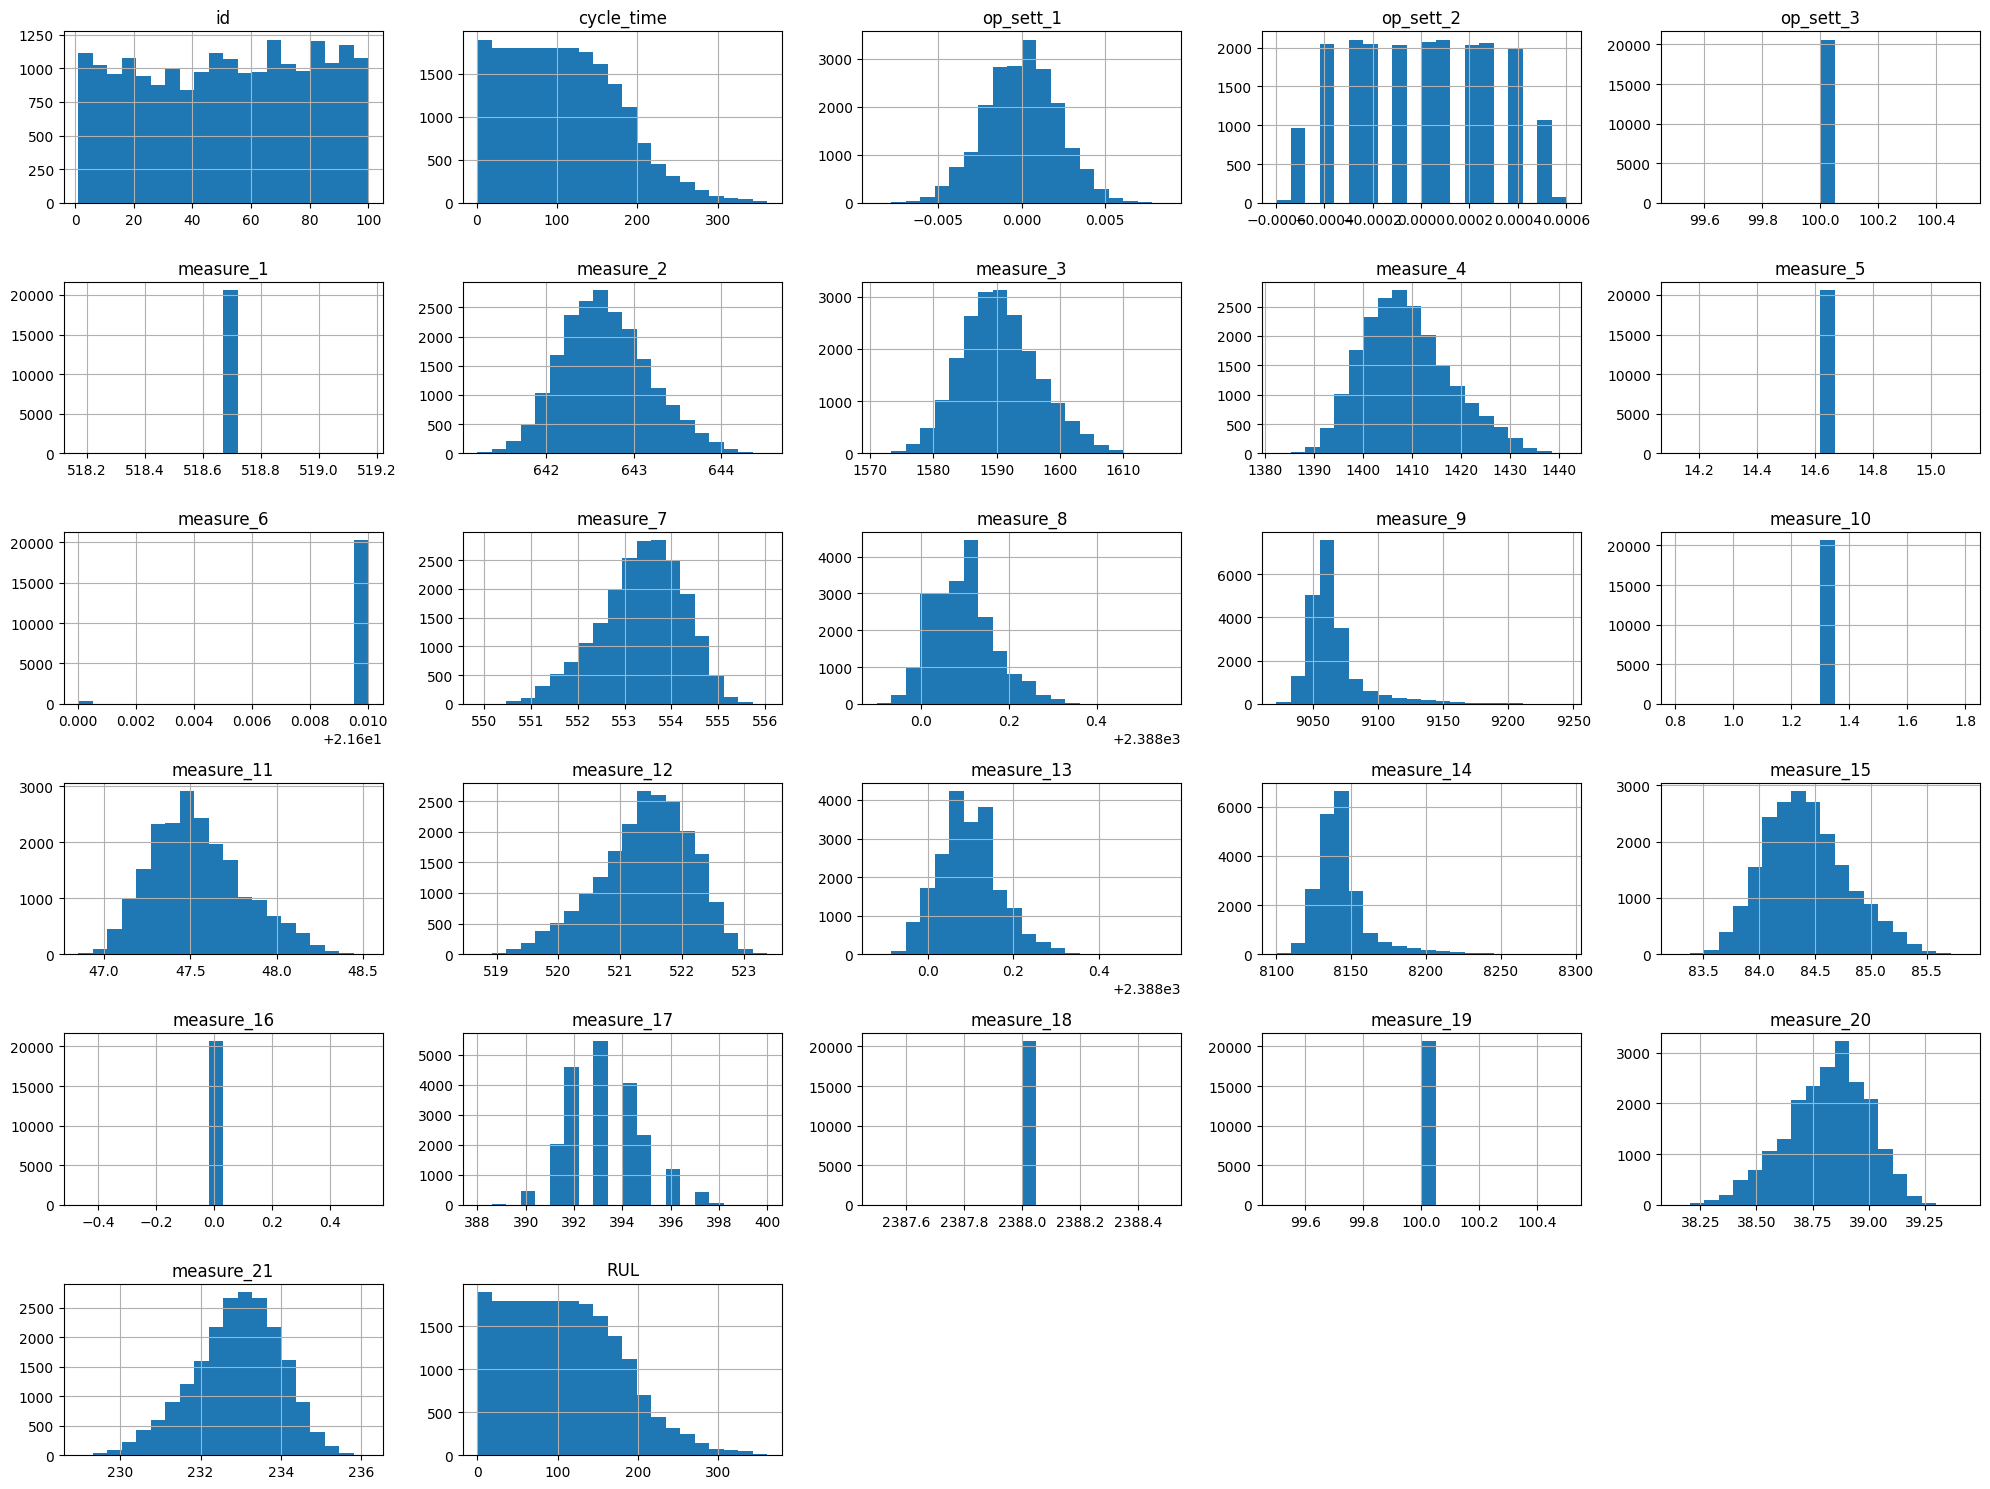

In [11]:
# Respuesta
import matplotlib.pyplot as plt

# Crear histogramas para todas las columnas
df_train.hist(bins=20, figsize=(20, 15))
plt.tight_layout()
plt.show()

# 1. Distribuciones constantes:
# E.g., las columnas en measure_1, measure_5, measure_6, measure_10, measure_19
# tienen valores constantes o casi constantes, reflejando una variabilidad
# insignificante en sus datos. Los histogramas muestran un único pico
# estrecho o valores agrupados.

# 2. Distribuciones sesgadas:
# cycle_time, measure_9, measure_14, RUL son distribuciones con un sesgo
# hacia la izquierda o derecha (asimétricas). E.g., la columna RUL está sesgada
# hacia la izquierda, lo que indica que la mayoría de los valores están
# concentrados en el rango inferior, probablemente cerca del final de la
# vida útil.

# 3. Distribuciones uniformes:
# E.g., id tiene distribuciones relativamente uniformes,
# lo que implica que los valores están distribuidos de manera aproximadamente
# equitativa a lo largo del rango.

# 4. Distribuciones normales:
# E.g., op_sett_1, measure_2, measure_3, measure_4, measure_7, measure_8,
# measure_11, measure_12, measure_15, measure_20, measure_21.
# Estas columnas muestran una distribución simétrica en forma de campana,
# típica de una distribución normal o gaussiana.

d) Una vez identificadas las columnas con valores constantes (es decir, aquellas columnas donde todos los valores son iguales), procede a eliminarlas del DataFrame `df_train`.

<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.25 puntos)**

In [12]:
# Respuesta
# Identificamos columnas con valores constantes
constant_columns = [col for col in df_train.columns if
                    df_train[col].nunique() == 1]
print("Columnas con valores constantes:", constant_columns)
# Eliminamos columnas constantes del DataFrame
df_train = df_train.drop(columns=constant_columns)
# Verificamos dimensiones después de la eliminación
print("\nDimensiones después de eliminar columnas constantes:", df_train.shape)

Columnas con valores constantes: ['op_sett_3', 'measure_1', 'measure_5', 'measure_10', 'measure_16', 'measure_18', 'measure_19']

Dimensiones después de eliminar columnas constantes: (20631, 20)


**Análisis de correlaciones**

El análisis de correlaciones permite evaluar el grado de relación lineal entre cada par de variables del conjunto de datos. Esto se observa en la matriz de correlación, que muestra los coeficientes de correlación entre todas las variables.

Objetivos:
- Identificar relaciones fuertes: Encuentra pares de variables con correlaciones altas (positivas o negativas). Nos permite seleccionar variables relevantes.
- Reducir la dimensionalidad: Si alguna variable no esta altamente correlacionada, considera eliminarlas.

e) Calcula la matriz de correlación del DataFrame obtenido en el punto anterior:
- Representa la matriz de correlación gráficamente.
- Detalla las relaciones más fuertes (positivas y negativas) y correlaciones débiles.
- Elimina las variables que no están altamente correlacionadas.




<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span>
 **(0.75 puntos)**


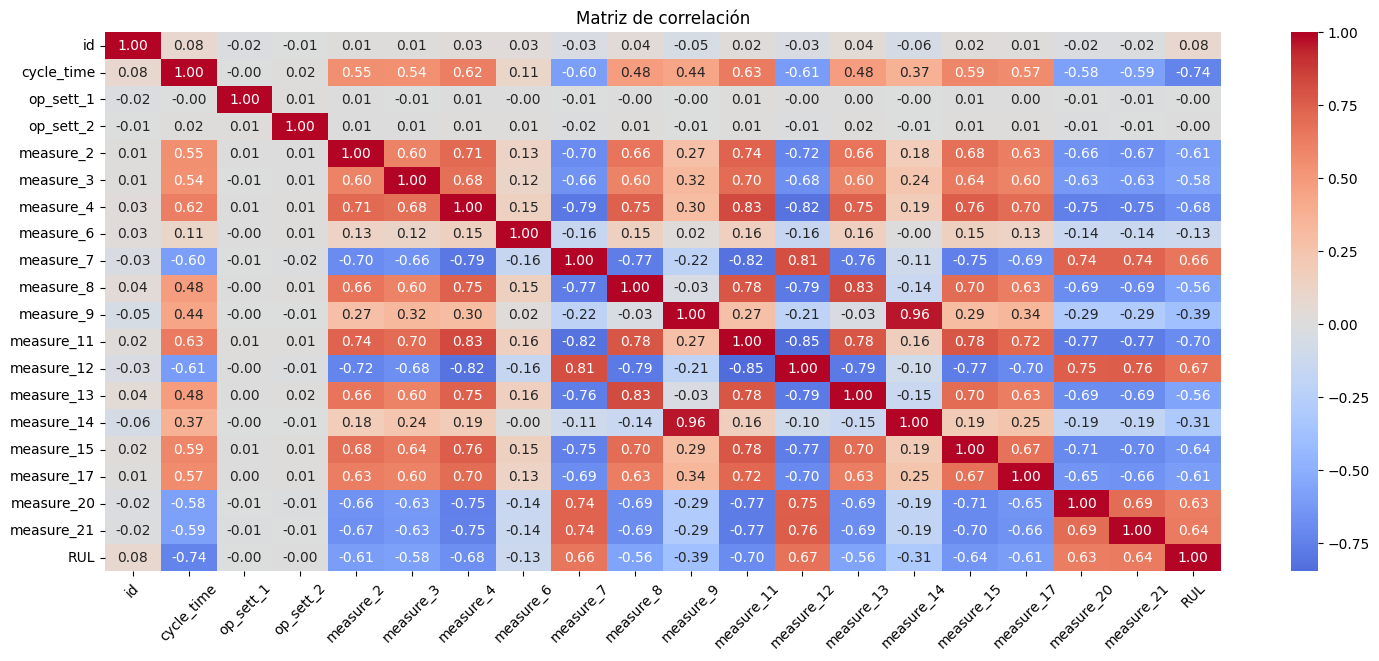

In [13]:
# Respuesta
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Calculamos la matriz de correlación
correlation_matrix = df_train.corr()

# Representación gráfica de la matriz de correlación con valores en cada celda
plt.figure(figsize=(18, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,            # Muestra los valores en las celdas
    fmt=".2f",             # Muestra dos decimales
    cmap='coolwarm',
    center=0,
    cbar=True              # Incluye la barra de colores
)
plt.title("Matriz de correlación")
plt.xticks(rotation=45)   # Rotamos etiquetas del eje x para legibilidad
plt.yticks(rotation=0)
plt.show()


# 1. Relaciones fuertes positivas:
# measure_3 y measure_4, measure_7 y measure_8, measure_11 y measure_15.
# Estas parejas son altamente correlacionadas y podrían ser redundantes.

# 2. Relaciones fuertes negativas:
# RUL con cycle_time y measure_9. Estas variables tienen relación inversa con
# la vida útil, relevantes para el análisis predictivo.

# 3. Correlaciones débiles:
# op_sett_2, measure_1, measure_5 y measure_6 tienen correlaciones débiles con
# otras variables, incluidas RUL, y podrían descartarse.

# 4. Reducción de dimensionalidad:
# Elimina variables constantes o débilmente correlacionadas como measure_1 y
# measure_5, y selecciona solo una de cada pareja altamente correlacionada
# para evitar redundancia.

In [14]:
# Respuesta
# Verificamos correlaciones bajas (< 0.3) en la matriz
min_correlations = correlation_matrix.min()
max_correlations = correlation_matrix.max()

# Imprimimos rangos de correlación por columna
print("Rango de correlación por columna:")
for col in correlation_matrix.columns:
    print(f"{col}: Min = {min_correlations[col]:.2f}, Max = {max_correlations[col]:.2f}")

# Identificamos columnas con correlación débil (< 0.3) con todas las demás variables
low_correlation_columns = [
    col for col in correlation_matrix.columns
    if (correlation_matrix[col].drop(col).abs().max() < 0.3)
]
print("\nColumnas con baja correlación (máxima correlación < 0.3 con otras):", low_correlation_columns)

Rango de correlación por columna:
id: Min = -0.06, Max = 1.00
cycle_time: Min = -0.74, Max = 1.00
op_sett_1: Min = -0.02, Max = 1.00
op_sett_2: Min = -0.02, Max = 1.00
measure_2: Min = -0.72, Max = 1.00
measure_3: Min = -0.68, Max = 1.00
measure_4: Min = -0.82, Max = 1.00
measure_6: Min = -0.16, Max = 1.00
measure_7: Min = -0.82, Max = 1.00
measure_8: Min = -0.79, Max = 1.00
measure_9: Min = -0.39, Max = 1.00
measure_11: Min = -0.85, Max = 1.00
measure_12: Min = -0.85, Max = 1.00
measure_13: Min = -0.79, Max = 1.00
measure_14: Min = -0.31, Max = 1.00
measure_15: Min = -0.77, Max = 1.00
measure_17: Min = -0.70, Max = 1.00
measure_20: Min = -0.77, Max = 1.00
measure_21: Min = -0.77, Max = 1.00
RUL: Min = -0.74, Max = 1.00

Columnas con baja correlación (máxima correlación < 0.3 con otras): ['id', 'op_sett_1', 'op_sett_2', 'measure_6']


In [15]:
# Respuesta
# Eliminamos las columnas con baja correlación usando la lista low_correlation_columns
df_train = df_train.drop(columns=low_correlation_columns)

# Imprimimos las columnas restantes
print(df_train.columns)

Index(['cycle_time', 'measure_2', 'measure_3', 'measure_4', 'measure_7',
       'measure_8', 'measure_9', 'measure_11', 'measure_12', 'measure_13',
       'measure_14', 'measure_15', 'measure_17', 'measure_20', 'measure_21',
       'RUL'],
      dtype='object')


## Ejercicio 3

La preparación de datos para la creación de un modelo de aprendizaje automático es un paso fundamental que garantiza que los datos estén en un **formato adecuado** para ser procesados por el modelo. Esto implica estructurar y transformar las variables para que sean compatibles con los algoritmos utilizados. Este proceso asegura que el modelo pueda interpretar correctamente los datos y extraer patrones relevantes, maximizando su capacidad predictiva y eficiencia computacional.

La variable target (en nuestro caso la llamaremos label) es esencial en un problema de clasificación, ya que representa las categorías o clases que el modelo debe aprender a predecir. En este caso, estamos interesados en predecir si un motor está próximo a fallar. Para ello, definimos una condición específica:


a) Consideraremos que un motor está próximo a fallar si su vida útil restante es menor o igual a 10 ciclos. Crear una nueva columna llamada **`label`** en el DataFrame `train_df` que tenga los siguientes valores:
- 1 si el valor de RUL es menor o igual a 10 (próximo a fallar).
- 0 si el valor de RUL es mayor a 10 (funcionamiento normal).

<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.25 puntos)**


In [16]:
# Respuesta
# Creamos la columna 'label' basada en la condición dada
df_train['label'] = (df_train['RUL'] <= 10).astype(int)

# Imprimimos la columna
print("Distribución de la columna 'label':")
print(df_train['label'].value_counts())

Distribución de la columna 'label':
label
0    19531
1     1100
Name: count, dtype: int64


b) Identificar el balance de las clases del conjunto de datos.
- Verifica con un gráfico el balance en la variable label.
- Crea un numpy array de atributos (input features) excluyendo las columnas RUL y label. Este array contendrá solo las variables que se usarán como entrada para el modelo. Guárdalo en la variable **`x_class`** . Crea otro numpy array solamente para la variable label. Guárdalo en la variable **`y_class`** (este tiene que ser unidimensional, es clase target).



<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.5 puntos)**

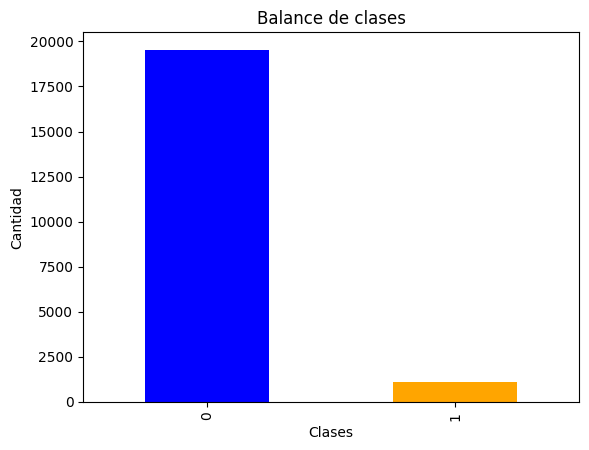

Dimensiones de x_class: (20631, 15)
Dimensiones de y_class: (20631,)


In [17]:
# Respuesta
import matplotlib.pyplot as plt
import numpy as np

# Verificamos el balance de clases con un gráfico
df_train['label'].value_counts().plot(kind='bar', color=['blue', 'orange'], title="Balance de clases")
plt.xlabel('Clases')
plt.ylabel('Cantidad')
plt.show()

# Creamos los arrays de entrada y salida
x_class = df_train.drop(columns=['RUL', 'label']).values  # Excluimos 'RUL' y 'label'
y_class = df_train['label'].values  # Variable target (debe ser unidimensional)

print("Dimensiones de x_class:", x_class.shape)
print("Dimensiones de y_class:", y_class.shape)

**Remuestreo**

En ML es habitual encontrarse con dataset desequilibrados, donde las clases no están representadas equitativamente. Este desequilibrio puede afectar negativamente al rendimiento de los modelos.

c) Aplicar una técnica de sobremuestreo para equilibrar las clases:
- Aplicar la técnica de sobremuestreo aleatorio utilizando la librería `imblearn` para equilibrar las clases. Como resultado obtendrías nuevos conjuntos de datos balanceados: `x_resampled` (atributos) y `y_resampled` (etiquetas).
- Comprueba la distribución de las clases después de aplicar el sobremuestreo.

**Notas:**

El sobremuestreo consiste en duplicar instancias o registros aleatoriamente de la clase minoritaria. Por otro lado, se debe tener en cuenta que también existe la técnica submuestreo aún más sencilla que consiste en eliminar registros de la clase dominante aleatoriamente.

<span style="font-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px; ">EI</span> **(0.75 puntos)**

Distribución de clases después del sobremuestreo:
Counter({0: 19531, 1: 19531})


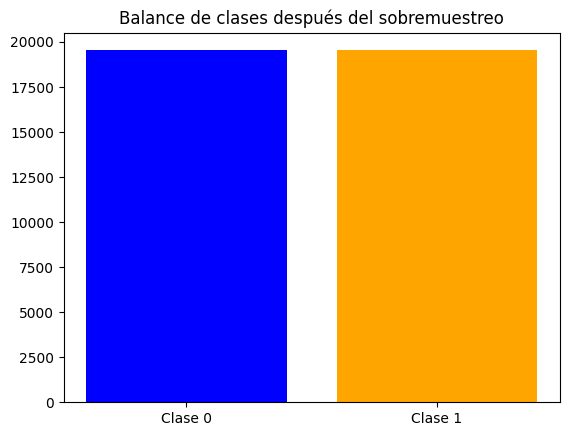

In [18]:
# Respuesta
from imblearn.over_sampling import RandomOverSampler

# Creamos el sobremuestreador
ros = RandomOverSampler(random_state=42)

# Aplicamos sobremuestreo
x_resampled, y_resampled = ros.fit_resample(x_class, y_class)

# Verificamos el balance de las clases después del sobremuestreo
from collections import Counter
print("Distribución de clases después del sobremuestreo:")
print(Counter(y_resampled))

# Visualizamos el balance después del sobremuestreo
plt.bar(['Clase 0', 'Clase 1'], [Counter(y_resampled)[0], Counter(y_resampled)[1]], color=['blue', 'orange'])
plt.title("Balance de clases después del sobremuestreo")
plt.show()

**Normalización de los datos**

La normalización o estandarización de los datos es el procedimiento de adaptar los datos con el objetivo que estos se asemejen dentro de un rango definido, de esta manera se consigue eliminar el efecto de las distintas escalas de medida y de tal manera que los algoritmos funcionen mejor.

Existen diferentes técnicas para la normalización de datos, pero en este ejercicio se aplicará el escalado de variables MinMax. En la ecuación tenemos que, se resta a cada observación el valor mínimo y se divide entre el rango observado. Hay que tener en cuenta que de esta manera los datos se comprimen, esto quiere decir si hay ruido, este será ampliado y los datos pueden quedar distorsionados.
$$
Xnorm = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
$$

d) Normaliza los datos y:
 - Utiliza la variable `features` para guardar el resultado.
 - Detalla brevemente otra técnica de estandarización de datos.
 - Muestra la dimensión.

**Nota:**

Ten en cuenta que en este caso que los labels(y_resampled) ya son binarios. Y no es necesario aplicar OneHotEncoder.

Utiliza la normalización de escalado de variables entre 1 y 0, de la librería `scikit-learn` que contiene la implementación del **MinMaxScaler.**

<span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0.5 puntos)**

In [20]:
# Respuesta
from sklearn.preprocessing import MinMaxScaler
# Creamos el escalador MinMaxScaler
scaler = MinMaxScaler()
# Aplicamos la normalización a los datos sobremuestreados
features = scaler.fit_transform(x_resampled)
# Verificamos las dimensiones después de la normalización
print("Dimensiones de features normalizadas:", features.shape)

# Otra técnica de estandarización:
# La estandarización z-score transforma los datos restando la media y
# dividiendo por la desviación estándar:
# Xnorm = (X - mean) / std
# Ello asegura que los datos tengan una media de 0 y desviación estándar de 1.

Dimensiones de features normalizadas: (39062, 15)


**Separación de los datos**

Después de equilibrar el conjunto de datos mediante técnicas como el sobremuestreo y normalizarlo, el siguiente paso es dividir el conjunto en subconjuntos de entrenamiento y validación. Este proceso es esencial en el desarrollo de un modelo predictivo porque permite entrenar el modelo en un conjunto de datos mientras se evalúa su desempeño en un conjunto separado y no utilizado durante el entrenamiento.

e) Divide los datos balanceados (features y y_resampled) en cuatro subconjuntos:
- `x_train`: datos de entrada que se utilizarán para entrenar el modelo.
- `x_val`: datos de entrada que se utilizarán para evaluar el modelo.
- `y_train`:  etiquetas asociadas a los datos de entrenamiento (x_train).
- `y_val`: etiquetas asociadas a los datos de validación (x_val).


**Notas:**

Usa la función train_test_split de `sklearn` para dividir los datos en un 80% para entrenamiento y 20% para validación.


<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span>
 **(0.5 puntos)**

In [21]:
# Respuesta
from sklearn.model_selection import train_test_split

# Dividimos los datos en subconjuntos de entrenamiento y validación
x_train, x_val, y_train, y_val = train_test_split(features, y_resampled, test_size=0.2, random_state=42)

# Imprimimos las dimensiones de los subconjuntos
print("Dimensiones de x_train:", x_train.shape)
print("Dimensiones de x_val:", x_val.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_val:", y_val.shape)

Dimensiones de x_train: (31249, 15)
Dimensiones de x_val: (7813, 15)
Dimensiones de y_train: (31249,)
Dimensiones de y_val: (7813,)


## Ejercicio 4

**Modelos**

Los árboles de decisión son uno de los algoritmos más importantes y usados en el machine learning, se forman a partir de reglas binarias (sí y no) con las que se consigue repartir las observaciones en función de sus atributos y determinar así el valor de la variable dependiente. Los árboles de decisión constan de nodos que forman un árbol de raíces, lo que significa que es un árbol dirigido con un nodo raíz que no tiene aristas entrantes.


a) Crea el árbol y entrena el modelo.
  - Para crear el árbol de decisión utilizaremos los hiperparámetros max_depth=4 y criterion='gini', el resto de hiperparámetros los dejaremos por defecto.
  - Grafica la estructura del árbol creado.


**Notas:**

Debéis utilizar la clase sklearn.tree.DecisionTreeClassifier.


<span style="font-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px; ">EI</span> **(1 punto)**

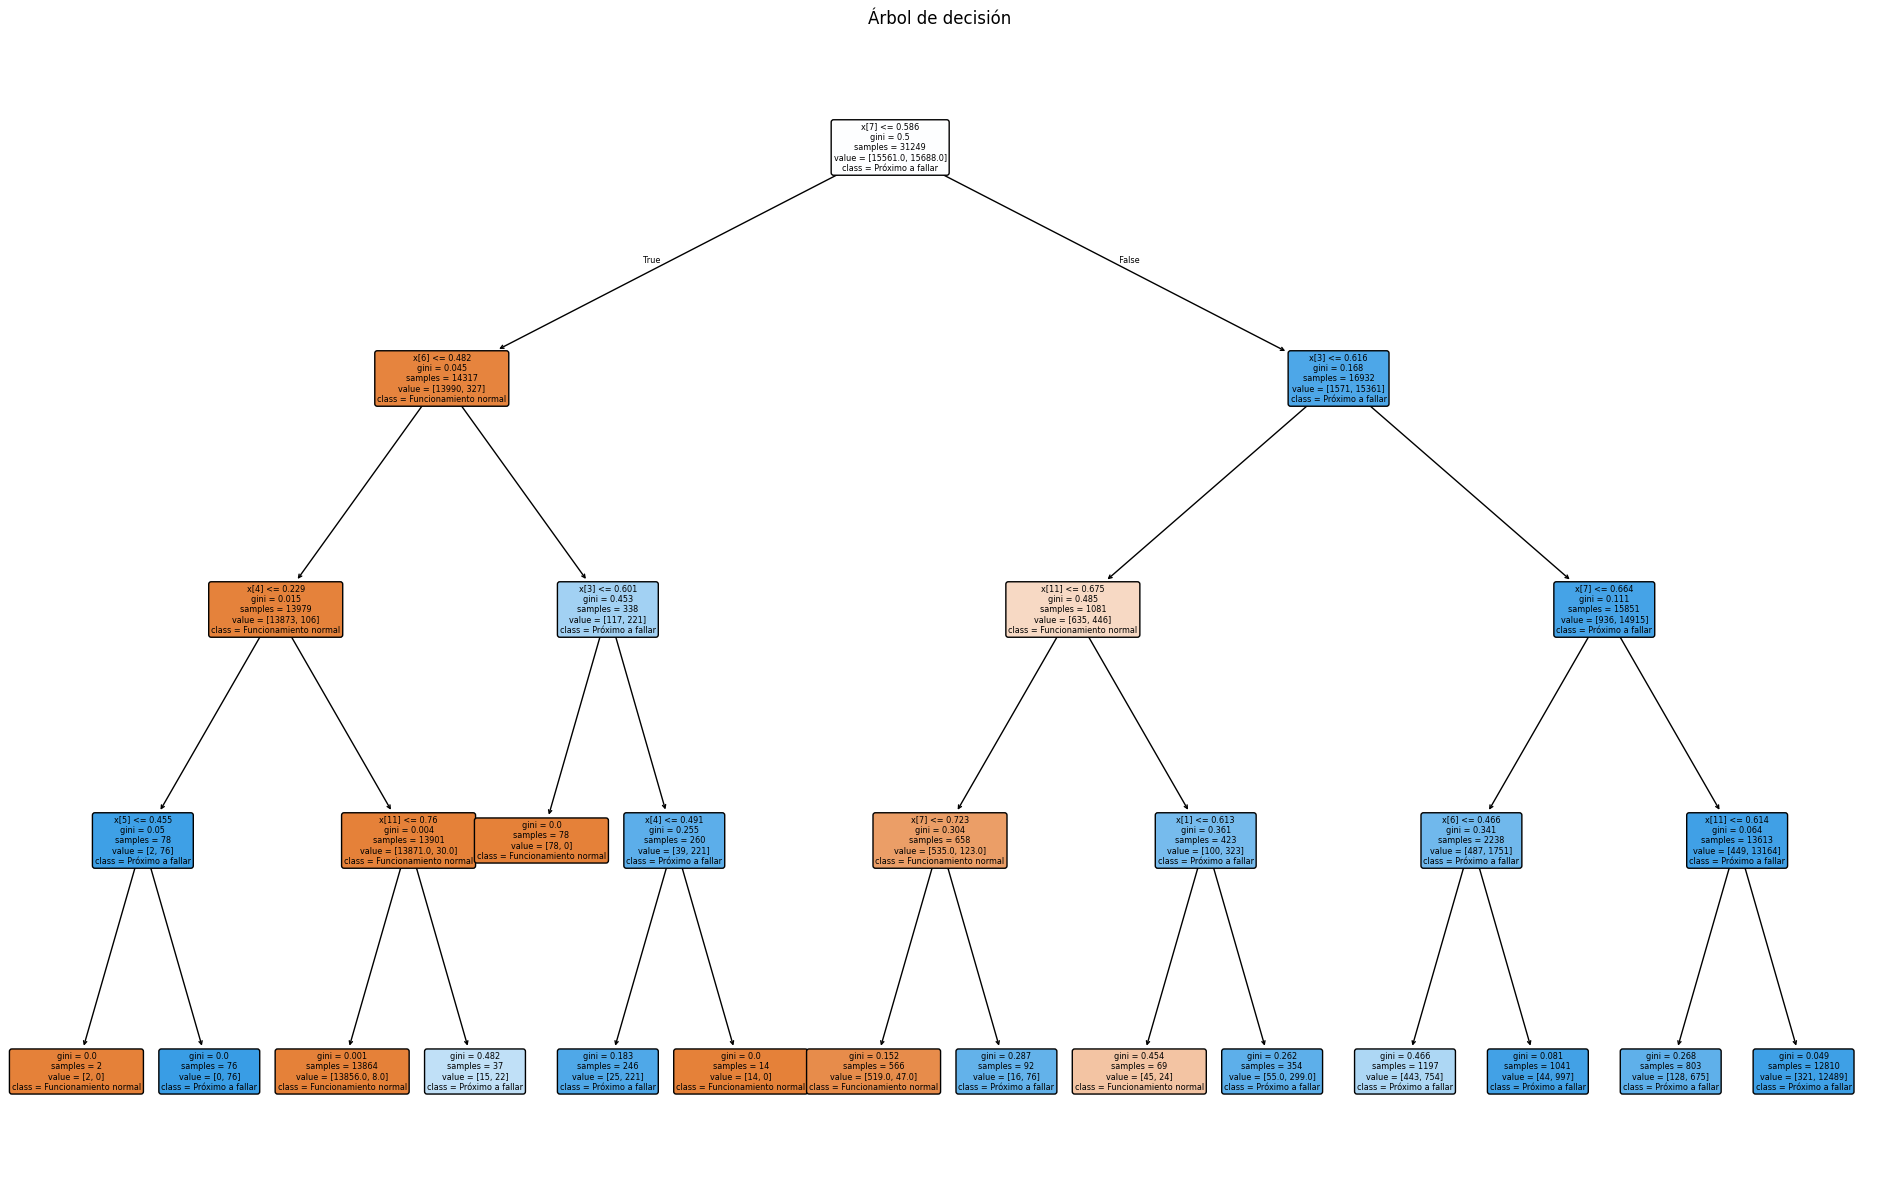

In [23]:
# Respuesta
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Creamos el árbol de decisión con los hiperparámetros especificados
tree_clf = DecisionTreeClassifier(max_depth=4, criterion='gini',
                                  random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
tree_clf.fit(x_train, y_train)

# Visualizamos la estructura del árbol
plt.figure(figsize=(24, 15))
plot_tree(tree_clf, feature_names=None, class_names=
 ['Funcionamiento normal', 'Próximo a fallar'], filled=True, rounded=True)
plt.title("Árbol de decisión")
plt.show()

b) Genera predicciones en el set de validación.

<span style="font-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px; ">EI</span> **(0.25 puntos)**

In [25]:
# Respuesta
from sklearn.metrics import classification_report, accuracy_score

# Generamos predicciones en el conjunto de validación
y_pred = tree_clf.predict(x_val)

# Evaluamos las predicciones
print("Reporte de clasificación:")
print(classification_report(y_val, y_pred,target_names=
      ['Funcionamiento normal', 'Próximo a fallar']))
# Calculamos la precisión global
accuracy = accuracy_score(y_val, y_pred)
print(f"Precisión del modelo: {accuracy:.2f}")

Reporte de clasificación:
                       precision    recall  f1-score   support

Funcionamiento normal       0.99      0.92      0.96      3970
     Próximo a fallar       0.92      0.99      0.96      3843

             accuracy                           0.96      7813
            macro avg       0.96      0.96      0.96      7813
         weighted avg       0.96      0.96      0.96      7813

Precisión del modelo: 0.96


## Ejercicio 5

**Evaluación del modelo en el set de validación**

Para poder saber si los resultados obtenidos de los modelos son buenos, lo primero que hay que plantearse es, ¿en qué se basa esta afirmación? Las métricas nos proporcionan esta base. La elección de la métrica correcta es crucial a la hora de evaluar los modelos de aprendizaje automático, dependiendo de la tarea en cuestión, existen diferentes métricas: las métricas más utilizadas en los problemas de clasificación son la Accuracy, la precisión, recall, f1-score, ROC y AUC y cuando se trata de problemas de regresión, solemos utilizar el MSE, el MAE o el R2.

a) Evalúa el modelo.
- Calcula y grafica la matriz de confusión.
- Calcula el reporte de clasificación.

**Notas:**

Para graficar la matriz de confusión se recomienda usar la clase ConfusionMatrixDisplay de `sklearn`.

<span style="font-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px; ">EI</span> **(0.5 puntos)**

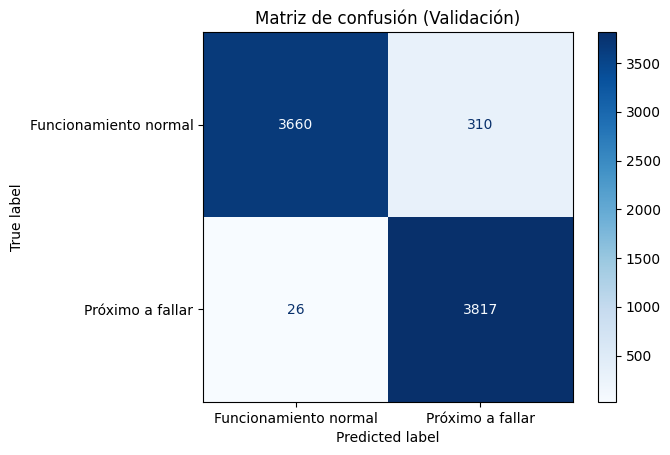

Reporte de clasificación (Validación):
                       precision    recall  f1-score   support

Funcionamiento normal       0.99      0.92      0.96      3970
     Próximo a fallar       0.92      0.99      0.96      3843

             accuracy                           0.96      7813
            macro avg       0.96      0.96      0.96      7813
         weighted avg       0.96      0.96      0.96      7813



In [31]:
# Respuesta
# La matriz de confusión se relaciona con las ideas de hipótesis cierta y
# hipótesis falsa en el contexto de pruebas estadísticas, pero aplicada a la
# clasificación en machine learning. En este caso, la hipótesis se refiere a
# la predicción del modelo sobre si una muestra pertenece a una clase o no.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculamos la matriz de confusión
conf_matrix = confusion_matrix(y_val, y_pred)

# Graficamos la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=
       ['Funcionamiento normal', 'Próximo a fallar'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión (Validación)")
plt.show()

from sklearn.metrics import classification_report
# Generamos el reporte de clasificación
print("Reporte de clasificación (Validación):")
print(classification_report(y_val, y_pred, target_names=
 ['Funcionamiento normal', 'Próximo a fallar']))

b) ¿Qué indican los resultados de validación sobre la capacidad del modelo para generalizar?

<span style="font-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px; ">EI</span> **(0.25 puntos)**

# Respuesta

El modelo tiene una precisión general del 96%, con altos valores de recall (99%) para casos de "Próximo a fallar" y pocos errores críticos (26 falsos negativos). Esto indica una capacidad sólida para generalizar, especialmente al identificar correctamente fallos potenciales, minimizando riesgos en nuevas predicciones.

**Predicción y evaluación del modelo en el set de test**

Al inicio, se comentó que el conjunto de datos está compuesto por tres ficheros. Hasta ahora, solamente hemos utilizado el fichero de entrenamiento, del cual hemos separado un 20% para validación. Sin embargo, tenemos un set específico para las pruebas. También contamos con un fichero donde se encuentran los labels del set de pruebas.

c) Realiza lo siguiente:

- Carga y normaliza el dataset de pruebas **`PM_test.csv`**, este dataset solamente necesita ser normalizado para que se pueda generar predicciones.
- Carga el fichero de groundtruth **`PM_truth.csv`** aquí tenemos solamente una columna con los labels del set de test. Preparálos de la manera correcta para que puedas evaluar.
- Muestra las primeras filas y también las dimensiones de los ficheros.
  
<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span> **(0.75 puntos)**


In [52]:
# Respuesta
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Cargamos el dataset de prueba (con el separador ;)
df_test = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/prog_datasci_7/data/PM_test.csv", sep=';')
df_truth = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/prog_datasci_7/data/PM_truth.csv")

# Normalizamos los datos de prueba
scaler = MinMaxScaler()
x_test = scaler.fit_transform(df_test)

# Preparamos los labels del set de prueba
y_test = df_truth.squeeze()  # Convertimos en una serie unidimensional si es necesario

# Imprimimos las primeras filas y dimensiones
print("Primeras filas del dataset de prueba:")
print(df_test.head())
print("\nDimensiones del dataset de prueba:", df_test.shape)
print("Dimensiones del archivo de labels:", df_truth.shape)

Primeras filas del dataset de prueba:
   cycle_time  measure_2  measure_3  measure_4  measure_7  measure_8  \
0          31     642.58    1581.22    1398.91     554.42    2388.08   
1          49     642.55    1586.59    1410.83     553.52    2388.10   
2         126     642.88    1589.75    1418.89     552.59    2388.16   
3         106     642.78    1594.53    1406.88     552.64    2388.13   
4          98     642.27    1589.94    1419.36     553.29    2388.10   

   measure_9  measure_11  measure_12  measure_13  measure_15  measure_17  \
0    9056.40       47.23      521.79     2388.06      84.024         393   
1    9044.77       47.67      521.74     2388.09      84.505         391   
2    9049.26       47.88      520.83     2388.14      84.119         395   
3    9051.30       47.65      521.88     2388.11      84.634         395   
4    9053.99       47.46      521.00     2388.15      84.362         394   

   measure_20  measure_21  
0       38.81     233.552  
1       38.81   

d) Con los datos normalizados, genera predicciones con el modelo del ejercicio anterior y:
- Calcula solamente el accuracy del modelo.
- Calcula y grafica la matriz de confusión.

<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span> **(0.5 puntos)**


## Ejercicio opcional


El potenciador del gradiente (Gradient Boosting), es un algoritmo de aprendizaje automático que se utiliza para problemas de regresión y clasificación, puede ser interpretado como un algoritmo de optimización en una función de coste adecuada. Se basa en un modelo de aprendizaje por conjuntos denominado boosting o potenciación.

a) Entrena un modelo utilizando el algoritmo de Gradient Boosting.

b) Genera predicciones en el set de test y también:

 - Calcula el accuracy del modelo
 - Genera y grafica la matriz de confusión

c) Responde a las siguientes preguntas:
- ¿Son los resultados mejores o peores que los del Árbol de decisión?
- ¿Por qué motivo han mejorado o empeorado?

**Notas:**

En este ejercicio utiliza la clase **XGBClassifier** de la librería `xgboost`, con el mismo enfoque planteado anteriormente en el Árbol de Decisión y utilizando los mismos datos en entrada ya preprocesados.


<span style="font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span>

Bibliografía

Universitat Oberta de Catalunya. (09/2022). prog_datasci_7_analisis.pdf. https://aula.uoc.edu/courses/47714

PEC7 - Aleem Karim Saeed